# Playground Series — Predicting Airline Satisfaction

Binary classification of `satisfaction` (`True` / `False`), scored with **ROC-AUC**. Submissions are
probabilities of `True`; only their ranking matters, so calibration is irrelevant.

**Data:** 699,635 train / 299,844 test rows, synthetic, generated from the *Airline Passenger Satisfaction*
dataset. Each row is one passenger: 4 categorical fields (gender, customer type, type of travel, class),
4 continuous fields (age, flight distance, departure and arrival delay) and 13 service ratings on a 0–5 scale.
One difference from the original is worth noting up front: the original survey has 14 ratings, and
`Inflight service` is not part of this dataset.

The synthetic labels are much noisier than the original's. Models on the original survey reach an AUC around
0.99, while here the models plateau near 0.959, so improvements from this point on come in ten-thousandths.

**Plan:** Overview → EDA → Preprocessing & feature engineering → the original dataset as rows and as
features → block ablation on CV → 5-fold CV with LightGBM / XGBoost / CatBoost → rank blend → submission.

**Current result:** LightGBM + XGBoost + CatBoost on the raw features plus original-data and exact-value
encodings, rank blend — OOF AUC 0.96078, public LB 0.96029.

In [45]:
import os
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, log_loss
from scipy.optimize import minimize
from scipy.stats import rankdata, ks_2samp

import lightgbm as lgb
import xgboost as xgb
import catboost as cb

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 200)

SEED = 42
TARGET = 'satisfaction'
N_SPLITS = 5

DATA_DIR = '../data'
PRED_DIR = '../preds'        # OOF / test predictions per model, so a dead kernel does not mean retraining
SUB_DIR = '../submission'
os.makedirs(PRED_DIR, exist_ok=True)
os.makedirs(SUB_DIR, exist_ok=True)

In [46]:
train_df = pd.read_csv(f'{DATA_DIR}/train.csv')
test_df = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/sample_submission.csv')
orig_df = pd.read_csv(f'{DATA_DIR}/original_data.csv')      # the original survey, used from section 3a on

assert set(orig_df.columns) == set(train_df.columns) - {'id'}, 'original data has a different column layout'

# The target is stored as True/False. Depending on the parser it arrives as bool or as strings;
# comparing the string form handles both.
for df in (train_df, orig_df):
    assert df[TARGET].notna().all(), 'target has missing values'
    df[TARGET] = df[TARGET].astype(str).str.strip().str.lower().eq('true').astype('int8')

print('Train shape   :', train_df.shape)
print('Test shape    :', test_df.shape)
print('Sub shape     :', sample_sub.shape)
print('Original shape:', orig_df.shape)

train_df.head()

Train shape   : (699635, 23)
Test shape    : (299844, 22)
Sub shape     : (299844, 2)
Original shape: (129880, 22)


,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,1,3,4,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
1,1,56,651,5,5,5,5,5,4,4,5,5,5,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,1
2,2,31,1371,3,4,2,5,3,3,3,3,4,3,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,0
3,3,10,1616,3,5,3,3,3,3,3,3,4,5,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,0
4,4,23,481,3,4,3,4,5,3,5,5,5,4,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,0


## 1. Data Overview

In [47]:
CAT_COLS = ['Gender', 'Customer Type', 'Type of Travel', 'Class']
CONT_COLS = ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']
RATING_COLS = [
    'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking',
    'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
    'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling',
    'Checkin service', 'Cleanliness',
]
NUM_COLS = CONT_COLS + RATING_COLS

assert set(CAT_COLS + NUM_COLS) == set(test_df.columns) - {'id'}, 'column groups do not match the data'

print('--- dtypes ---')
print(train_df.dtypes.value_counts())

print('\n--- continuous features ---')
display(train_df[CONT_COLS].describe().T.round(2))

print('--- service ratings ---')
display(pd.DataFrame({
    'min': train_df[RATING_COLS].min(),
    'max': train_df[RATING_COLS].max(),
    'n_unique': train_df[RATING_COLS].nunique(),
    'mean': train_df[RATING_COLS].mean().round(3),
}))

print('--- categorical levels ---')
for c in CAT_COLS:
    print(f'{c}: {train_df[c].value_counts(dropna=False).to_dict()}')

--- dtypes ---
int64      17
str         4
float64     1
int8        1
Name: count, dtype: int64

--- continuous features ---


,count,mean,std,min,25%,50%,75%,max
Age,699635.0,39.00,13.80,7.0,27.0,40.0,50.0,85.0
Flight Distance,699635.0,1353.78,954.42,67.0,631.0,954.0,1814.0,4983.0
Departure Delay in Minutes,699635.0,1.18,5.98,0.0,0.0,0.0,0.0,489.0
Arrival Delay in Minutes,699343.0,1.13,5.75,0.0,0.0,0.0,0.0,491.0


--- service ratings ---


,min,max,n_unique,mean
Inflight wifi service,0,5,6,2.779
Departure/Arrival time convenient,0,5,6,3.156
Ease of Online booking,0,5,6,2.813
Gate location,0,5,6,3.014
Food and drink,0,5,6,3.266
Online boarding,0,5,6,3.364
Seat comfort,0,5,6,3.569
Inflight entertainment,0,5,6,3.454
On-board service,0,5,6,3.517
Leg room service,0,5,6,3.473


--- categorical levels ---
Gender: {'Male': 351683, 'Female': 347952}
Customer Type: {'Loyal Customer': 576990, 'disloyal Customer': 122645}
Type of Travel: {'Business travel': 497441, 'Personal Travel': 202194}
Class: {'Business': 342212, 'Eco': 327404, 'Eco Plus': 30019}


A few things to keep in mind before plotting:

- **Service ratings use the original survey's 0–5 scale, where 0 means "not applicable"** — the passenger did
  not use or did not rate that service — rather than "worst". So a 0 need not sit below a 1 in terms of
  satisfaction, and the rating heatmap below shows that for some services it sits far above. `Baggage handling`
  is the exception, with no 0 at all (1–5), as in the original.
- **The delays are almost always zero.** Both delay columns have a median *and* a 75th percentile of 0 and a
  mean of about 1.2 minutes, with a thin tail out to roughly 490 minutes. That is far more concentrated than in
  the original survey, so in this version the delays carry little information. The plots use `log1p` for them;
  the tree models do not need the transform, since splits are invariant to monotone rescaling.
- **All categoricals are low-cardinality** (2–3 levels). `Class` has a natural order
  (Eco < Eco Plus < Business), so it is encoded ordinally; the other three are binary. Eco Plus is small:
  30,019 rows, 4.3% of train.

In [48]:
# Missing values: train vs test
na_tbl = pd.DataFrame({
    'train_na': train_df.drop(columns=[TARGET]).isna().sum(),
    'train_na_%': (train_df.drop(columns=[TARGET]).isna().mean() * 100).round(3),
    'test_na': test_df.isna().sum(),
    'test_na_%': (test_df.isna().mean() * 100).round(3),
})
na_tbl = na_tbl[(na_tbl['train_na'] > 0) | (na_tbl['test_na'] > 0)]

if len(na_tbl):
    display(na_tbl)
else:
    print('No missing values in train or test.')

n_dup = train_df.duplicated(subset=CAT_COLS + NUM_COLS).sum()
print(f'\nTrain rows duplicating an earlier feature vector: {n_dup:,}')

,train_na,train_na_%,test_na,test_na_%
Arrival Delay in Minutes,292,0.042,130,0.043



Train rows duplicating an earlier feature vector: 0


`Arrival Delay in Minutes` is the only column with gaps: 292 rows in train and 130 in test, about 0.04% of
each. There are no duplicated feature vectors.

**No imputation is needed.** LightGBM, XGBoost and CatBoost all learn a default direction for NaN at every
split, and mean or median imputation would only blend the "unknown" rows into an ordinary value. With 292 rows
affected, the choice has no measurable effect on the score either way.

## 2. EDA

               count    pct
satisfaction               
0             389296  55.64
1             310339  44.36

base rate P(satisfied) = 0.4436 | sample_submission constant = 0.4436


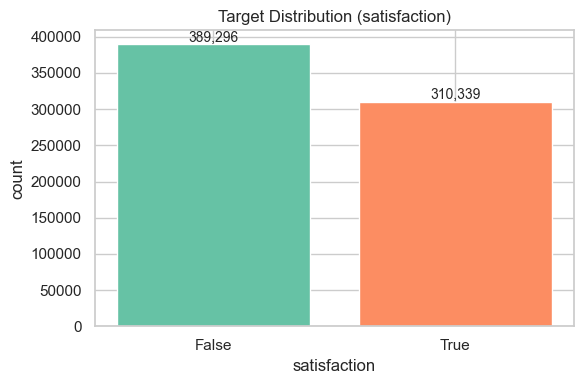

In [49]:
# Target distribution
target_counts = train_df[TARGET].value_counts().sort_index()
base_rate = train_df[TARGET].mean()

print(pd.DataFrame({'count': target_counts, 'pct': (target_counts / len(train_df) * 100).round(2)}))
print(f'\nbase rate P(satisfied) = {base_rate:.4f} | sample_submission constant = {sample_sub[TARGET].iloc[0]:.4f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['False', 'True'], target_counts.values, color=sns.color_palette('Set2')[:2])
ax.set_title('Target Distribution (satisfaction)')
ax.set_xlabel('satisfaction'); ax.set_ylabel('count')
for i, v in enumerate(target_counts.values):
    ax.annotate(f'{v:,}', (i, v), ha='center', va='bottom', fontsize=10)
plt.tight_layout(); plt.show()

44.36% of passengers are satisfied (310,339 of 699,635). The constant in `sample_submission.csv` (0.4436) is
exactly this base rate: the trivial baseline, worth AUC 0.5.

This is a mild imbalance, and AUC is insensitive to class balance anyway, so class weights or resampling would
not help. `StratifiedKFold` keeps the ratio identical across folds.

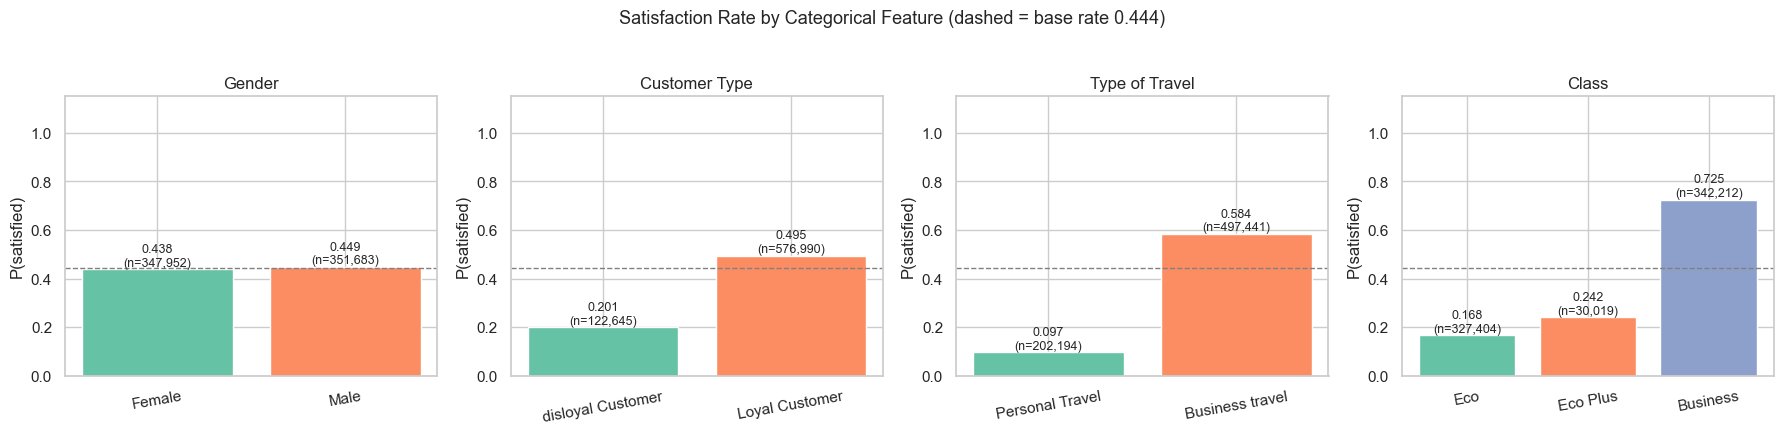

In [50]:
# Satisfaction rate per categorical level
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2))
colors = sns.color_palette('Set2')

for ax, col in zip(axes, CAT_COLS):
    g = train_df.groupby(col)[TARGET].agg(['mean', 'count']).sort_values('mean')
    ax.bar(g.index.astype(str), g['mean'], color=colors[:len(g)])
    ax.axhline(base_rate, ls='--', c='grey', lw=1)
    for i, (v, n) in enumerate(zip(g['mean'], g['count'])):
        ax.annotate(f'{v:.3f}\n(n={n:,})', (i, v), ha='center', va='bottom', fontsize=9)
    ax.set_title(col); ax.set_ylabel('P(satisfied)'); ax.set_ylim(0, 1.15)
    ax.tick_params(axis='x', rotation=10)

plt.suptitle(f'Satisfaction Rate by Categorical Feature (dashed = base rate {base_rate:.3f})', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()

`Class` and `Type of Travel` carry most of the categorical signal:

- **Class:** 72.5% of Business-class passengers are satisfied, against 24.2% in Eco Plus and 16.8% in Eco.
- **Type of Travel:** 58.4% on business trips versus 9.7% on personal travel, the largest single gap in the
  data.
- **Customer Type:** 49.5% for loyal customers, 20.1% for disloyal ones.
- **Gender:** 43.8% vs 44.9%, about half a point either side of the base rate, so close to no signal.

The two strong features overlap heavily, though: business travellers are the ones who fly Business class.
The interaction plot further down separates the two effects.

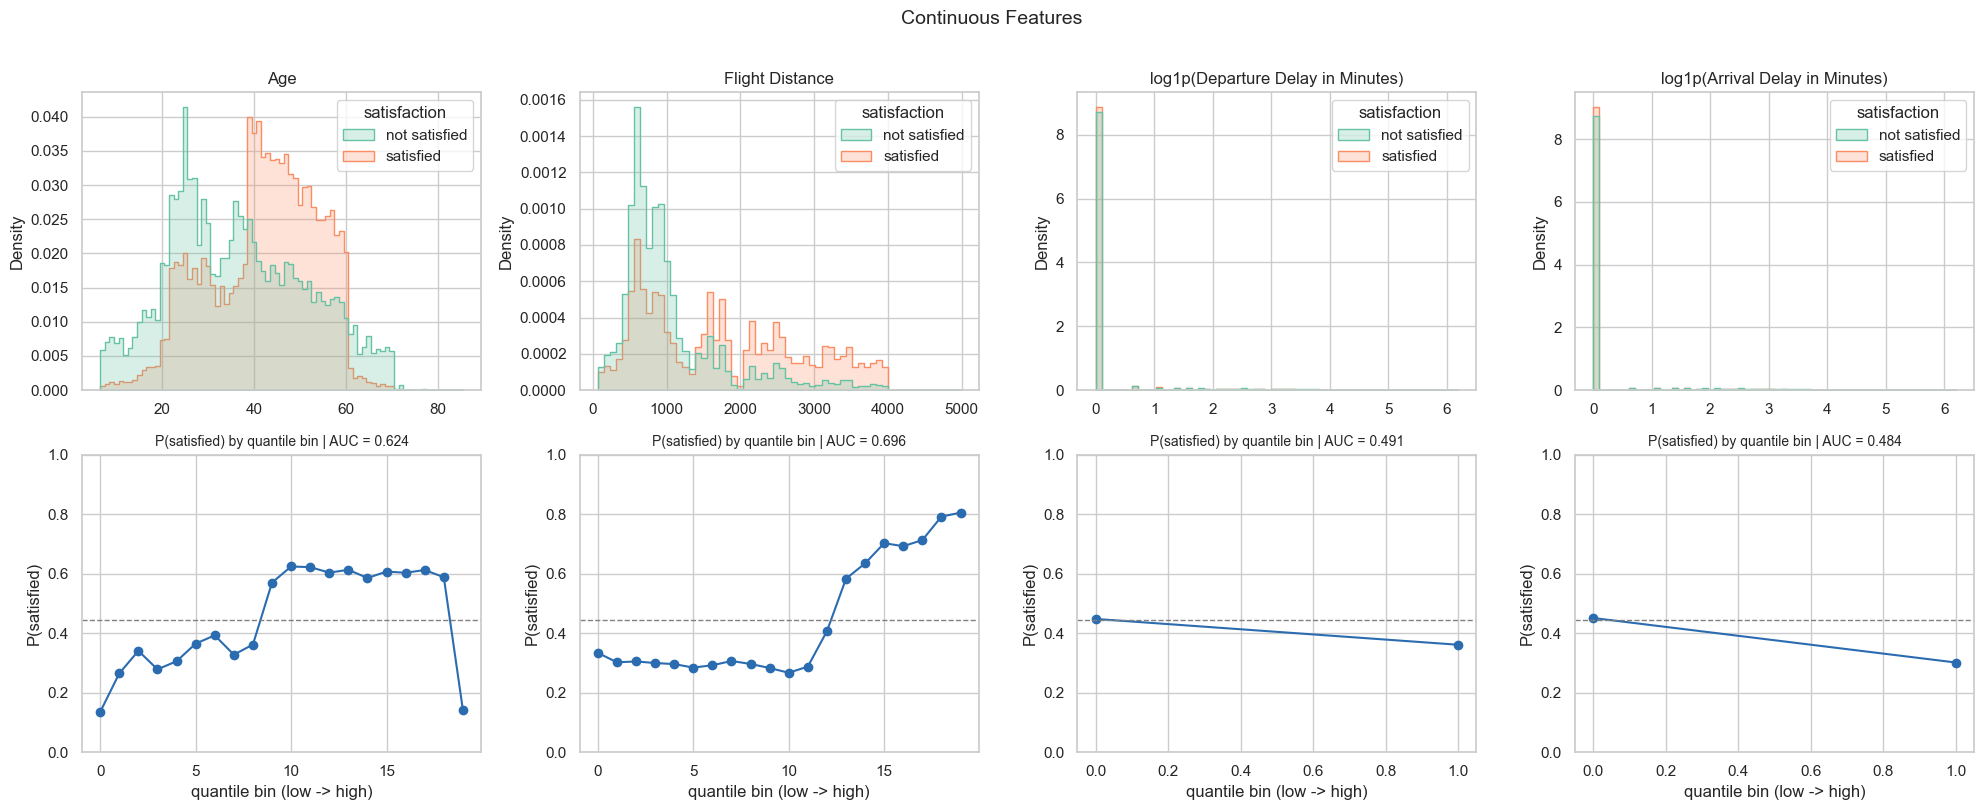

In [51]:
# Continuous features: distribution by target (top) and target rate per quantile bin (bottom)
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
single_auc = {}

for i, col in enumerate(CONT_COLS):
    data = train_df[[col, TARGET]].dropna()
    is_delay = 'Delay' in col
    label = data[TARGET].map({0: 'not satisfied', 1: 'satisfied'})

    # Age is an integer: one bin per year. With 60 equal-width bins some bins would hold two ages
    # and others one, which draws regular false spikes.
    hist_kw = dict(discrete=True) if col == 'Age' else dict(bins=60)

    ax = axes[0, i]
    sns.histplot(x=np.log1p(data[col]) if is_delay else data[col], hue=label, **hist_kw,
                 stat='density', common_norm=False, element='step', palette='Set2', ax=ax)
    ax.set_title(f'log1p({col})' if is_delay else col); ax.set_xlabel('')

    # 5% quantile slices; the zero-heavy delay columns collapse into fewer bins
    bins = pd.qcut(data[col], 20, duplicates='drop')
    rate = data.groupby(bins, observed=True)[TARGET].mean()
    single_auc[col] = roc_auc_score(data[TARGET], data[col])

    ax = axes[1, i]
    ax.plot(range(len(rate)), rate.values, marker='o', color='#2b6cb0')
    ax.axhline(base_rate, ls='--', c='grey', lw=1)
    ax.set_ylim(0, 1)
    ax.set_title(f'P(satisfied) by quantile bin | AUC = {single_auc[col]:.3f}', fontsize=10)
    ax.set_xlabel('quantile bin (low -> high)'); ax.set_ylabel('P(satisfied)')

plt.suptitle('Continuous Features', fontsize=14, y=1.01)
plt.tight_layout(); plt.show()

How to read the bottom row: each point is the satisfaction rate within a 5% quantile slice, so the curve shows
the *shape* of the relationship, which a single AUC number cannot. An AUC below 0.5 means higher values go with
lower satisfaction.

- **`Age` (AUC 0.624) is a plateau, not a slope.** Satisfaction sits around 0.3 for passengers under about 40,
  steps up to roughly 0.6 between 40 and 60, then collapses to 0.14 in the oldest 5%. The youngest slice is
  just as low. A shape like that is worth more than its AUC suggests, and trees capture it with a few splits.
- **`Flight Distance` (AUC 0.696) is flat, then steep.** The rate stays near 0.3 for the shorter ~60% of
  flights and climbs to about 0.8 for the longest ones. This is largely a proxy: long-haul flights are dominated
  by business travellers in Business class.
- **The delays are close to useless here.** With more than 75% zeros, the quantile bins collapse into just
  "zero" and "non-zero". A non-zero delay does lower the rate (from 0.45 to 0.36 for departure, to 0.30 for
  arrival), but so few passengers have one that the single-feature AUC stays at 0.49 / 0.48. LightGBM ranks
  both delay columns at the bottom of its feature importance.

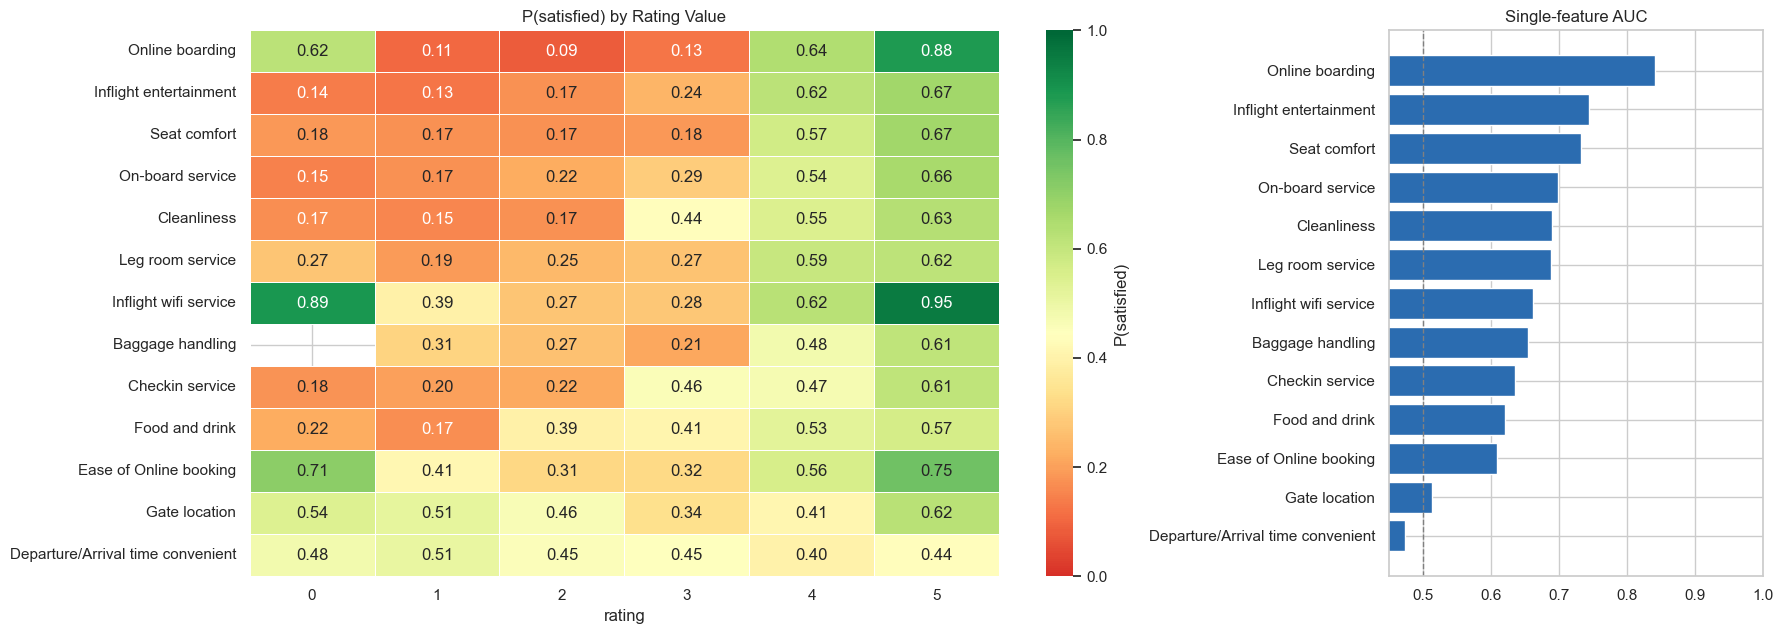

Share of rows per rating value (%):


,0,1,2,3,4,5
Online boarding,1.31,8.23,17.05,21.41,30.15,21.85
Inflight entertainment,0.15,10.02,16.20,17.58,30.03,26.02
Seat comfort,0.12,9.02,13.22,17.18,32.41,28.06
On-board service,0.11,8.74,12.44,21.56,32.30,24.86
Cleanliness,0.14,10.37,14.66,24.29,27.25,23.29
Leg room service,0.24,7.59,18.12,18.81,29.18,26.07
Inflight wifi service,1.87,15.40,26.71,26.36,18.31,11.34
Baggage handling,NaN,4.35,8.37,18.63,39.68,28.97
Checkin service,0.13,9.50,10.71,28.61,29.96,21.09
Food and drink,0.14,10.14,21.28,22.09,24.14,22.21


In [52]:
# Service ratings: P(satisfied) for every rating value, rows sorted by single-feature AUC
rating_auc = pd.Series(
    {c: roc_auc_score(train_df[TARGET], train_df[c]) for c in RATING_COLS}
).sort_values(ascending=False)

rate_tbl = pd.DataFrame({c: train_df.groupby(c)[TARGET].mean() for c in RATING_COLS}).T
rate_tbl = rate_tbl.sort_index(axis=1).loc[rating_auc.index]
share_tbl = pd.DataFrame({c: train_df[c].value_counts(normalize=True) for c in RATING_COLS}).T
share_tbl = share_tbl.sort_index(axis=1).loc[rating_auc.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5), gridspec_kw={'width_ratios': [3, 1.2]})
sns.heatmap(rate_tbl, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, center=base_rate,
            linewidths=0.5, cbar_kws={'label': 'P(satisfied)'}, ax=axes[0])
axes[0].set_title('P(satisfied) by Rating Value'); axes[0].set_xlabel('rating'); axes[0].set_ylabel('')

axes[1].barh(rating_auc.index[::-1], rating_auc.values[::-1], color='#2b6cb0')
axes[1].axvline(0.5, ls='--', c='grey', lw=1)
axes[1].set_xlim(min(0.45, rating_auc.min() - 0.02), 1)
axes[1].set_title('Single-feature AUC')
plt.tight_layout(); plt.show()

print('Share of rows per rating value (%):')
display((share_tbl * 100).round(2))

This is the most informative plot in the EDA.

- **`Online boarding` is the strongest single feature by a wide margin** (AUC ≈ 0.84), and its shape is a
  threshold rather than a slope: 0.09–0.13 for ratings 1–3, then 0.64 at 4 and 0.88 at 5. The in-flight
  comfort items come next (`Inflight entertainment`, `Seat comfort`, `On-board service`, `Cleanliness`,
  `Leg room service`, AUC ≈ 0.69–0.75), with the same jump between 3 and 4.
- **The 0 column breaks the trend for the digital services.** A 0 on `Inflight wifi service` comes with 0.89
  satisfaction, against 0.39 at a rating of 1; `Ease of Online booking` (0.71) and `Online boarding` (0.62)
  behave the same way. For the comfort items, by contrast, 0 behaves like a low rating.
- **Wifi is U-shaped:** 0.89 at 0, 0.27–0.28 at 2–3, 0.95 at 5. Single-feature AUC (≈ 0.66) cannot see a U,
  which is why wifi ranks only seventh here but second in LightGBM's feature importance.
- **`Gate location` is U-shaped too** (0.34 at 3, 0.62 at 5) despite an AUC of ≈ 0.51.
  `Departure/Arrival time convenient` is the only rating that is genuinely flat (0.40–0.51).
- The share table shows how rare 0 is: at most 3.7% of rows (`Departure/Arrival time convenient`) and only
  0.1–0.2% for the comfort items, so the 0 rates for those are noisier than the rest of the heatmap.

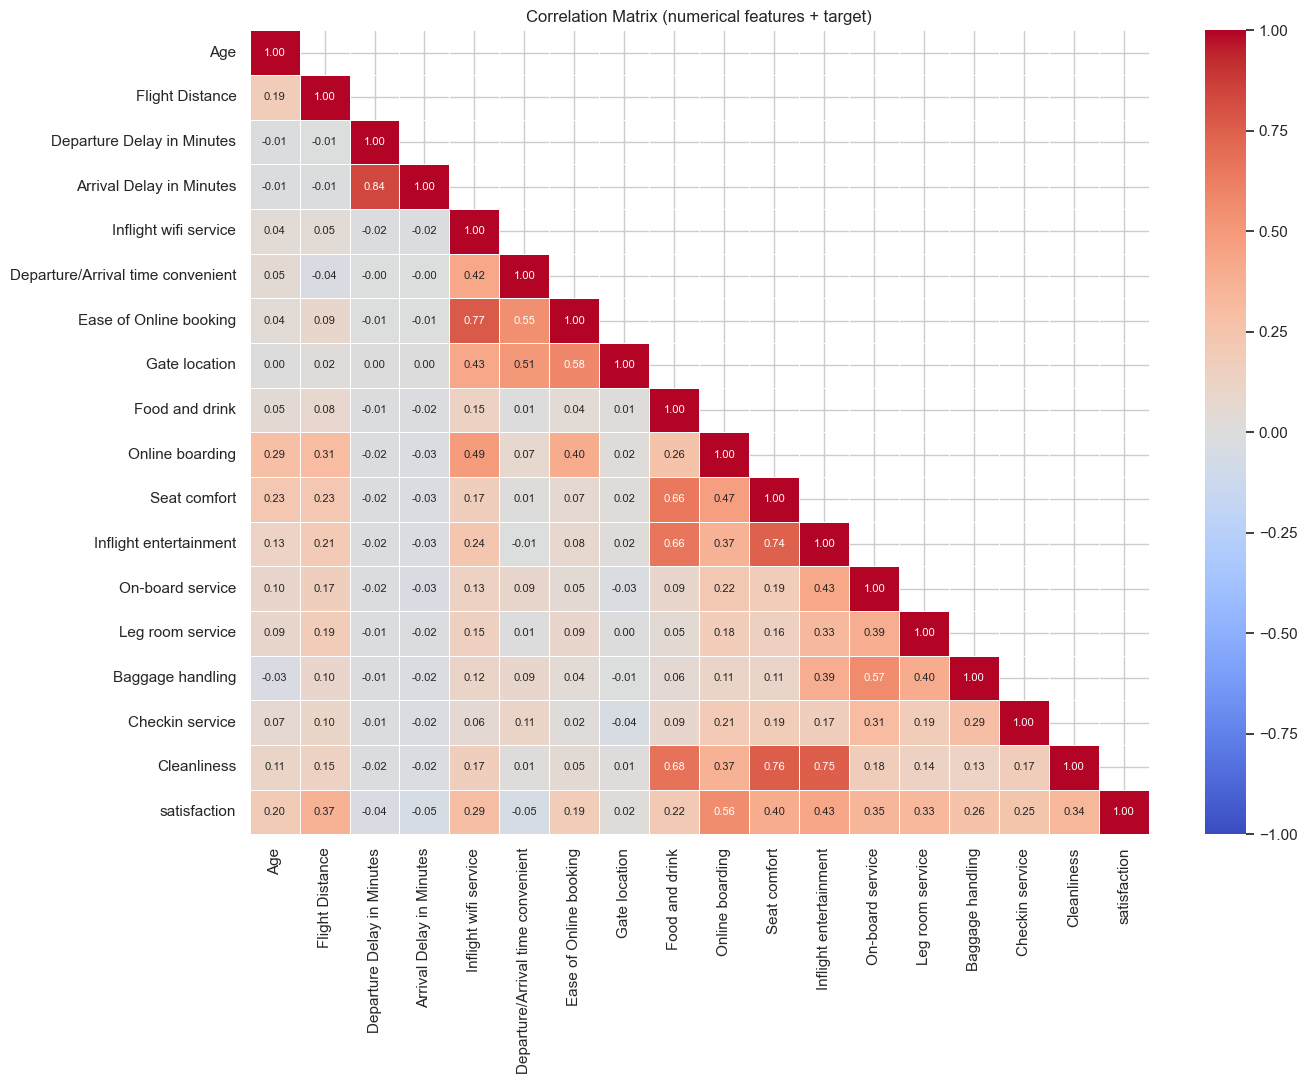

In [53]:
# Correlation matrix of the numerical features and the target
corr = train_df[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix (numerical features + target)')
plt.tight_layout(); plt.show()

- **`Departure Delay` and `Arrival Delay` correlate at 0.84**, strongly though less than in the original
  survey. Arrival delay is departure delay plus whatever was gained or lost in the air.
- **The ratings form clusters.** In-flight comfort: `Cleanliness`, `Seat comfort`, `Inflight entertainment`
  and `Food and drink` correlate at 0.66–0.76 with each other. Booking and the airport:
  `Inflight wifi service` ↔ `Ease of Online booking` at 0.77, with `Gate location` and
  `Departure/Arrival time convenient` loosely attached (0.42–0.58). A third, looser group joins
  `On-board service`, `Baggage handling` and `Leg room service` (0.39–0.57).
- **Against the target**, `Online boarding` leads (0.56), then `Inflight entertainment` (0.43),
  `Seat comfort` (0.40) and `Flight Distance` (0.37). These are linear correlations, so they understate the
  U-shaped ratings above.
- Tree models are robust to collinearity, so no columns are dropped.

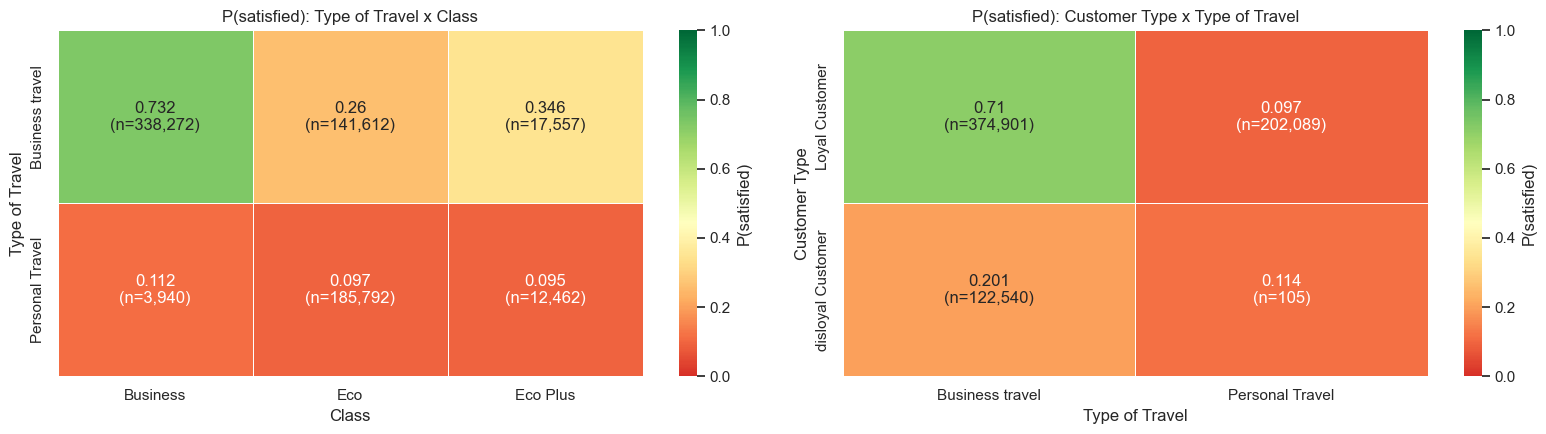

In [54]:
# Interactions between the strongest categoricals
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

for ax, (r, c) in zip(axes, [('Type of Travel', 'Class'), ('Customer Type', 'Type of Travel')]):
    pv = train_df.pivot_table(index=r, columns=c, values=TARGET, aggfunc='mean')
    cnt = train_df.pivot_table(index=r, columns=c, values=TARGET, aggfunc='size')
    annot = pv.round(3).astype(str) + '\n(n=' + cnt.map('{:,.0f}'.format) + ')'
    sns.heatmap(pv, annot=annot, fmt='', cmap='RdYlGn', vmin=0, vmax=1, center=base_rate,
                linewidths=0.5, cbar_kws={'label': 'P(satisfied)'}, ax=ax)
    ax.set_title(f'P(satisfied): {r} x {c}')

plt.tight_layout(); plt.show()

The left panel separates the two strongest categoricals, and the answer is an interaction rather than two
additive effects:

- **Personal travellers are dissatisfied whatever they fly:** 9.5% to 11.2% in every class, Business included.
- **For business travellers the class makes all the difference:** 73.2% satisfied in Business, 34.6% in
  Eco Plus, 26.0% in Eco.

The right panel shows that **disloyal customers are almost exclusively business travellers** (122,540 of
122,645), and that loyalty matters within that group: 71.0% satisfied for loyal business travellers against
20.1% for disloyal ones. Personal travel stays near 10% either way. Trees pick up interactions like these on
their own, with two consecutive splits.

In [55]:
# Train vs test drift: KS statistic for numerical columns, max share gap for categoricals
n = min(100_000, len(train_df), len(test_df))
tr_s = train_df.sample(n, random_state=SEED)
te_s = test_df.sample(n, random_state=SEED)

num_drift = pd.Series(
    {c: ks_2samp(tr_s[c].dropna(), te_s[c].dropna()).statistic for c in NUM_COLS}
).sort_values(ascending=False)

cat_drift = pd.Series({
    c: (train_df[c].value_counts(normalize=True) - test_df[c].value_counts(normalize=True)).abs().max()
    for c in CAT_COLS
}).sort_values(ascending=False)

display(num_drift.round(4).to_frame('KS statistic').T)
display(cat_drift.round(4).to_frame('max share gap').T)

,On-board service,Departure/Arrival time convenient,Inflight wifi service,Leg room service,Food and drink,Baggage handling,Ease of Online booking,Flight Distance,Cleanliness,Age,Checkin service,Online boarding,Seat comfort,Gate location,Departure Delay in Minutes,Inflight entertainment,Arrival Delay in Minutes
KS statistic,0.006,0.005,0.0047,0.0044,0.0042,0.004,0.0035,0.0034,0.003,0.0028,0.0025,0.0025,0.0025,0.0014,0.0011,0.0009,0.0007


,Gender,Customer Type,Class,Type of Travel
max share gap,0.0015,0.0014,0.0004,0.0002


Every KS statistic is at most 0.006 and every categorical share differs by at most 0.15 percentage points:
train and test are indistinguishable, as expected from a Playground split. The practical consequence is that
the cross-validation score should track the leaderboard, and every decision below is made on CV.

Every submission so far bears this out: the public LB has landed 0.0005–0.0006 below OOF each time
(see section 6), and the round 3 gain predicted by the ablation (+0.00170) showed up on the leaderboard at
exactly that size.

## 3. Preprocessing & Feature Engineering

**1) No imputation.** All three models handle NaN natively (see section 1).

**2) Categorical encoding.** Explicit mappings rather than `LabelEncoder`, so the codes are readable and an
unexpected level raises an error instead of silently becoming a new integer. The three binary columns become
0/1 and `Class` becomes ordinal (Eco 0, Eco Plus 1, Business 2). CatBoost additionally receives them as true
categoricals in section 4.

**3) Engineered features.** Trees split on one column at a time, so they cannot form a sum or an average
across columns no matter how deep they grow. With 13 ratings, the overall rating level is exactly that kind
of cross-column quantity:

- *Rating profile:* mean, std and max over all 13 ratings; mean and min over the rated (non-zero) ones;
  counts of 0s ("not applicable"), low ratings (1–2) and top ratings (5).
- *Rating groups:* the mean of the non-zero ratings within three clusters seen in the correlation matrix —
  digital (wifi, online booking, online boarding), ground (time convenience, gate, check-in, baggage) and
  comfort (seat, leg room, cleanliness, food, entertainment, on-board service).
- *Delays:* `total_delay`, `delay_diff` (arrival − departure: time lost or recovered in the air), and arrival
  delay per 100 miles, since an hour's delay weighs more on a short hop than on a long-haul flight.
- *Interaction:* `travel_class`, the six `Type of Travel` × `Class` combinations.

Column names are converted to snake_case at the end, which keeps them safe across all three libraries.
Section 3c then measures whether the engineered features actually help rather than assuming it, and
they do not.

In [56]:
CAT_MAPS = {
    'Gender': {'Female': 0, 'Male': 1},
    'Customer Type': {'disloyal Customer': 0, 'Loyal Customer': 1},
    'Type of Travel': {'Personal Travel': 0, 'Business travel': 1},
    'Class': {'Eco': 0, 'Eco Plus': 1, 'Business': 2},      # ordinal
}

RATING_GROUPS = {
    'digital': ['Inflight wifi service', 'Ease of Online booking', 'Online boarding'],
    'ground': ['Departure/Arrival time convenient', 'Gate location', 'Checkin service', 'Baggage handling'],
    'comfort': ['Seat comfort', 'Leg room service', 'Cleanliness', 'Food and drink',
                'Inflight entertainment', 'On-board service'],
}
assert sorted(sum(RATING_GROUPS.values(), [])) == sorted(RATING_COLS)

DEP, ARR = 'Departure Delay in Minutes', 'Arrival Delay in Minutes'


def encode(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, mapping in CAT_MAPS.items():
        unknown = set(df[col].dropna().unique()) - set(mapping)
        assert not unknown, f'{col}: unmapped levels {unknown}'
        df[col] = df[col].map(mapping).astype('float32')
    return df


def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    R = df[RATING_COLS]
    R_nz = R.where(R > 0)                   # 0 = "not applicable", not "worst"

    # --- overall rating profile ---
    df['rating_mean'] = R.mean(axis=1)
    df['rating_std'] = R.std(axis=1)
    df['rating_max'] = R.max(axis=1)
    df['rating_mean_nz'] = R_nz.mean(axis=1)
    df['rating_min_nz'] = R_nz.min(axis=1)
    df['n_zero'] = (R == 0).sum(axis=1)
    df['n_low'] = R.isin([1, 2]).sum(axis=1)
    df['n_top'] = (R == 5).sum(axis=1)

    # --- rating groups (non-zero ratings only) ---
    for name, cols in RATING_GROUPS.items():
        df[f'{name}_mean'] = df[cols].where(df[cols] > 0).mean(axis=1)

    # --- delays ---
    df['total_delay'] = df[DEP] + df[ARR]
    df['delay_diff'] = df[ARR] - df[DEP]    # > 0: delay grew in the air, < 0: time was recovered
    df['arr_delay_per_100mi'] = df[ARR] / df['Flight Distance'] * 100

    # --- strongest categorical interaction ---
    df['travel_class'] = df['Type of Travel'] * 3 + df['Class']

    return df


def clean_name(c: str) -> str:
    return re.sub(r'[^0-9a-zA-Z]+', '_', c).strip('_').lower()

In [57]:
train_fe = add_features(encode(train_df))
test_fe = add_features(encode(test_df))
orig_fe = add_features(encode(orig_df))

for df in (train_fe, test_fe, orig_fe):
    df.columns = [clean_name(c) for c in df.columns]
assert train_fe.columns.is_unique

BASE_FEATURES = [clean_name(c) for c in CAT_COLS + NUM_COLS]
ENG_FEATURES = [c for c in train_fe.columns if c not in BASE_FEATURES + ['id', TARGET]]
CAT_FEATURES = [clean_name(c) for c in CAT_COLS] + ['travel_class']

y = train_fe[TARGET].values
y_orig = orig_fe[TARGET].values
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
FOLDS = list(skf.split(train_fe, y))      # every experiment below reuses these exact folds

print(f'{len(BASE_FEATURES)} raw + {len(ENG_FEATURES)} engineered features')
display(train_fe[ENG_FEATURES].describe().T.round(3))

21 raw + 15 engineered features


,count,mean,std,min,25%,50%,75%,max
rating_mean,699635.0,3.309,0.683,0.769,2.846,3.308,3.769,5.000
rating_std,699635.0,1.106,0.363,0.000,0.855,1.080,1.363,2.444
rating_max,699635.0,4.744,0.488,1.000,5.000,5.000,5.000,5.000
rating_mean_nz,699635.0,3.334,0.674,1.000,2.846,3.385,3.846,5.000
rating_min_nz,699635.0,1.733,0.827,1.000,1.000,2.000,2.000,5.000
n_zero,699635.0,0.104,0.468,0.000,0.000,0.000,0.000,6.000
n_low,699635.0,3.571,2.880,0.000,1.000,4.000,5.000,13.000
n_top,699635.0,2.825,2.644,0.000,1.000,2.000,5.000,13.000
digital_mean,694205.0,3.041,1.049,1.000,2.333,3.000,4.000,5.000
ground_mean,699635.0,3.383,0.759,1.000,2.750,3.500,4.000,5.000


### 3a. The original dataset

`original_data.csv` is the survey the competition data was generated from: 129,880 rows in the same column
layout (without `Inflight service`), with real rather than synthetic labels. It can help in two ways:

- **As extra training rows**, appended to every training fold but never to validation, so the OOF score stays
  comparable with every earlier run.
- **As a source of features.** A model trained on the original alone has never seen a synthetic label, so its
  predictions on train and test are leakage-free inputs for the main models.

Two checks come first: how close the synthetic distributions are to the original's, and how well the
original's decision function carries over to the synthetic labels.

In [58]:
# Distribution shift between the original survey and the synthetic train
tr_s = train_df.sample(len(orig_df), random_state=SEED)

num_shift = pd.DataFrame({
    'KS': pd.Series({c: ks_2samp(orig_df[c].dropna(), tr_s[c].dropna()).statistic for c in NUM_COLS}),
    'mean orig': orig_df[NUM_COLS].mean(),
    'mean train': train_df[NUM_COLS].mean(),
}).round(4).sort_values('KS', ascending=False)
display(num_shift)

# Category shares and satisfaction rates side by side
cat_cmp = pd.concat({
    'share orig': pd.concat({c: orig_df[c].value_counts(normalize=True) for c in CAT_COLS}),
    'share train': pd.concat({c: train_df[c].value_counts(normalize=True) for c in CAT_COLS}),
    'P(sat) orig': pd.concat({c: orig_df.groupby(c)[TARGET].mean() for c in CAT_COLS}),
    'P(sat) train': pd.concat({c: train_df.groupby(c)[TARGET].mean() for c in CAT_COLS}),
}, axis=1).round(4)
display(cat_cmp)
print(f'base rate: original {orig_df[TARGET].mean():.4f} | synthetic train {train_df[TARGET].mean():.4f}')

# Exact copies: does any synthetic row reproduce an original feature vector?
key_cols = CAT_COLS + NUM_COLS
orig_keys = orig_df[key_cols + [TARGET]].drop_duplicates(subset=key_cols)
hits = train_df[key_cols + [TARGET]].merge(orig_keys, on=key_cols, how='inner', suffixes=('', '_orig'))
n_test_hits = len(test_df[key_cols].merge(orig_keys[key_cols], on=key_cols, how='inner'))
print(f'\ntrain rows matching an original row exactly: {len(hits):,} ({len(hits) / len(train_df):.3%})')
print(f'test rows matching an original row exactly : {n_test_hits:,} ({n_test_hits / len(test_df):.3%})')
if len(hits):
    print(f'label agreement on the matched train rows  : {(hits[TARGET] == hits[TARGET + "_orig"]).mean():.4f}')

,KS,mean orig,mean train
Arrival Delay in Minutes,0.3544,15.0911,1.1343
Departure Delay in Minutes,0.3434,14.7137,1.1762
Flight Distance,0.2161,1190.3164,1353.7787
Baggage handling,0.0665,3.6321,3.8054
On-board service,0.0472,3.3830,3.5174
Checkin service,0.0452,3.3063,3.4203
Seat comfort,0.0425,3.4414,3.5689
Leg room service,0.0403,3.3509,3.4728
Age,0.0363,39.4280,39.0019
Inflight entertainment,0.0352,3.3581,3.4539


share orig  share train  P(sat) orig  P(sat) train
Gender         Female                 0.5074       0.4973       0.4290        0.4380
               Male                   0.4926       0.5027       0.4401        0.4491
Customer Type  Loyal Customer         0.8169       0.8247       0.4781        0.4951
               disloyal Customer      0.1831       0.1753       0.2397        0.2009
Type of Travel Business travel        0.6906       0.7110       0.5837        0.5843
               Personal Travel        0.3094       0.2890       0.1013        0.0973
Class          Business               0.4786       0.4891       0.6944        0.7253
               Eco                    0.4489       0.4680       0.1877        0.1676
               Eco Plus               0.0725       0.0429       0.2464        0.2422

base rate: original 0.4345 | synthetic train 0.4436

train rows matching an original row exactly: 17 (0.002%)
test rows matching an original row exactly : 4 (0.001%)
label agreement on the matched train rows  : 0.8235


- **The ratings and `Age` were reproduced closely** (KS 0.02–0.07). **The delays were not:** KS 0.35, with the
  mean falling from about 15 minutes in the original to about 1.1 in the synthetic data. `Flight Distance`
  moved as well (KS 0.22, mean 1,190 → 1,354), and Eco Plus is under-represented (7.3% → 4.3%).
- **The label relationships carried over.** Per-category satisfaction rates sit within a few points of each
  other: Business class 0.694 vs 0.725, personal travel 0.101 vs 0.097. The largest gap is for disloyal
  customers (0.240 vs 0.201).
- **There are essentially no copies.** Only 17 train rows and 4 test rows match an original row exactly, so a
  label lookup has nothing to work with.

In [59]:
%%time
# LightGBM trained on the original survey alone. Its out-of-fold predictions on the original rows and its
# fold-averaged predictions on the synthetic train and test never involve a synthetic label, so they can be
# fed to the main models as a feature without any leakage.
orig_params = dict(
    objective='binary', metric='auc', n_estimators=5000, learning_rate=0.03,
    num_leaves=63, min_child_samples=20, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, random_state=SEED, n_jobs=-1, verbose=-1,
)
X_orig_raw = orig_fe[BASE_FEATURES]
ORIG_FOLDS = list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(X_orig_raw, y_orig))

orig_pred_orig = np.zeros(len(orig_fe))
orig_pred_train = np.zeros(len(train_fe))
orig_pred_test = np.zeros(len(test_fe))

for tr_idx, va_idx in ORIG_FOLDS:
    m = lgb.LGBMClassifier(**orig_params)
    m.fit(X_orig_raw.iloc[tr_idx], y_orig[tr_idx],
          eval_set=[(X_orig_raw.iloc[va_idx], y_orig[va_idx])],
          callbacks=[lgb.early_stopping(200, verbose=False)])
    orig_pred_orig[va_idx] = m.predict_proba(X_orig_raw.iloc[va_idx])[:, 1]
    orig_pred_train += m.predict_proba(train_fe[BASE_FEATURES])[:, 1] / N_SPLITS
    orig_pred_test += m.predict_proba(test_fe[BASE_FEATURES])[:, 1] / N_SPLITS

print(f'original model, OOF AUC on the original labels  : {roc_auc_score(y_orig, orig_pred_orig):.6f}')
print(f'original model, AUC on the synthetic train      : {roc_auc_score(y, orig_pred_train):.6f}')
print('for reference, round 1 LightGBM trained on train: 0.959041 (OOF)')

original model, OOF AUC on the original labels  : 0.995205
original model, AUC on the synthetic train      : 0.954740
for reference, round 1 LightGBM trained on train: 0.959041 (OOF)
CPU times: user 3min 54s, sys: 1min 19s, total: 5min 13s
Wall time: 1min


The original model scores 0.9952 on its own labels but 0.9547 on the synthetic ones. That is only 0.0043 below
the LightGBM trained on the synthetic data itself, although it has never seen a synthetic label. So the
generator kept the original's decision function, and most of what makes this competition harder is label
noise: a model that ranks the original passengers almost perfectly loses 0.04 AUC on the synthetic ones.

That made both uses of the original data plausible, and section 3c split them apart. As training rows the
original *hurts*, most likely because its delay and distance distributions differ so much from the synthetic
ones. As a source of features it helps.

### 3b. Candidate feature blocks

Each block is tested in section 3c:

| block | what it adds |
|---|---|
| `orig_pred` | the original model's prediction from section 3a |
| `orig_te` | for every raw column, the satisfaction rate per exact value *in the original data*, smoothed toward the original base rate: a per-column view of the clean relationship |
| `freq` | how often each exact value of `Age`, `Flight Distance` and the two delays occurs in train + test; values the generator over- or under-produces stand out |
| `te` | out-of-fold target encoding of `Age` and `Flight Distance` on the *synthetic* labels |
| `te_delay` | the same for the two delay columns (round 4 candidate) |
| `te_pair` | the same for category × number pairs: `Class` and `Type of Travel` × `Flight Distance`; `Class`, `Type of Travel` and `Customer Type` × `Age` (round 4 candidate) |
| `eng` | the round 1 engineered features (rejected: −0.000311, t = −4.21), kept so they can be re-tested |

The `te*` blocks need care. `Flight Distance` has thousands of distinct values, too many for trees to isolate one
by one, so the encoding hands each value's satisfaction rate to the model directly. Because it uses synthetic
labels, it is rebuilt inside every fold: validation, test and original rows are encoded with the fold's training
rows only, and the training rows themselves get an inner out-of-fold encoding. No row's encoding ever contains
its own label or a validation label. A pair is encoded the same way, with the two values combined into one key.

The two original-based blocks follow the same rule for the original rows: when those rows are appended to
training, their `orig_pred` and `orig_te` values come from models and statistics that did not see them.

In [ ]:
TE_SMOOTH = 20                                       # default smoothing: (sum + k * prior) / (count + k)
FREQ_COLS = [clean_name(c) for c in CONT_COLS]
FRAMES = {'train': train_fe, 'test': test_fe, 'orig': orig_fe}

# Fold-dependent target-encoding blocks: each entry is a column, or a combination encoded as one key
TE_SPECS = {
    'te': [('age',), ('flight_distance',)],
    'te_delay': [('departure_delay_in_minutes',), ('arrival_delay_in_minutes',)],
    'te_pair': [('class', 'flight_distance'), ('type_of_travel', 'flight_distance'),
                ('class', 'age'), ('type_of_travel', 'age'), ('customer_type', 'age')],
}


def smoothed_rate(keys, target, prior, smooth=TE_SMOOTH):
    """Satisfaction rate per exact value, shrunk toward the prior for rare values."""
    g = pd.DataFrame({'k': np.asarray(keys), 't': target}).groupby('k')['t'].agg(['sum', 'count'])
    return (g['sum'] + smooth * prior) / (g['count'] + smooth)


def encode_oof(keys, target, folds, prior, smooth=TE_SMOOTH):
    """Out-of-fold smoothed_rate: every row is encoded with statistics that exclude it."""
    keys = pd.Series(np.asarray(keys))
    out = np.full(len(keys), np.nan)
    for tr_idx, va_idx in folds:
        rate = smoothed_rate(keys.iloc[tr_idx], target[tr_idx], prior, smooth)
        out[va_idx] = keys.iloc[va_idx].map(rate).to_numpy()
    return out


def te_key(df, cols):
    """One numeric key per row for a column combination (every value is a non-negative integer < 1e5)."""
    key = df[cols[0]].astype('float64')
    for c in cols[1:]:
        key = key * 1e5 + df[c].astype('float64')
    return key


TE_KEYS = {}
for cols in {s for specs in TE_SPECS.values() for s in specs}:
    for c in cols:
        for df in FRAMES.values():
            v = df[c].dropna()
            assert v.between(0, 99_999).all() and (v == v.round()).all(), f'{c} cannot be packed into a key'
    TE_KEYS[cols] = {p: te_key(df, cols) for p, df in FRAMES.items()}


# --- orig_te: per-value rates from the original labels (out-of-fold on the original rows) ---
prior_orig = y_orig.mean()
orig_te = {p: {} for p in FRAMES}
for c in BASE_FEATURES:
    rate = smoothed_rate(orig_fe[c], y_orig, prior_orig)
    orig_te['train'][f'orig_te_{c}'] = train_fe[c].map(rate).to_numpy()
    orig_te['test'][f'orig_te_{c}'] = test_fe[c].map(rate).to_numpy()
    orig_te['orig'][f'orig_te_{c}'] = encode_oof(orig_fe[c], y_orig, ORIG_FOLDS, prior_orig)

# --- freq: value counts over the synthetic train + test ---
freq = {p: {} for p in FRAMES}
for c in FREQ_COLS:
    counts = pd.concat([train_fe[c], test_fe[c]]).value_counts()
    for p, df in FRAMES.items():
        freq[p][f'freq_{c}'] = df[c].map(counts).to_numpy(dtype='float64')

STATIC_BLOCKS = {
    'orig_pred': {'train': {'orig_pred': orig_pred_train}, 'test': {'orig_pred': orig_pred_test},
                  'orig': {'orig_pred': orig_pred_orig}},
    'orig_te': orig_te,
    'freq': freq,
}
STATIC_BLOCKS = {b: {p: pd.DataFrame(cols[p], index=FRAMES[p].index) for p in FRAMES}
                 for b, cols in STATIC_BLOCKS.items()}
STATIC_BLOCKS['eng'] = {p: FRAMES[p][ENG_FEATURES] for p in FRAMES}


def fold_te(tr_idx, va_idx, specs, smooth):
    """te encodings for one outer fold -> DataFrames for (training rows, validation rows, test, original)."""
    y_tr = y[tr_idx]
    prior = y_tr.mean()
    inner = list(StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(tr_idx, y_tr))
    parts = {'tr': {}, 'va': {}, 'test': {}, 'orig': {}}
    for cols in specs:
        name = 'te_' + '_x_'.join(cols)
        keys = TE_KEYS[cols]
        keys_tr = keys['train'].iloc[tr_idx]
        rate = smoothed_rate(keys_tr, y_tr, prior, smooth)
        parts['tr'][name] = encode_oof(keys_tr, y_tr, inner, prior, smooth)
        parts['va'][name] = keys['train'].iloc[va_idx].map(rate).to_numpy()
        parts['test'][name] = keys['test'].map(rate).to_numpy()
        parts['orig'][name] = keys['orig'].map(rate).to_numpy()
    index = {'tr': train_fe.index[tr_idx], 'va': train_fe.index[va_idx],
             'test': test_fe.index, 'orig': orig_fe.index}
    return tuple(pd.DataFrame(parts[p], index=index[p]) for p in ('tr', 'va', 'test', 'orig'))


def build_matrices(blocks=()):
    """Full train / test / original matrices: raw features plus the fold-independent blocks."""
    unknown = set(blocks) - set(STATIC_BLOCKS) - set(TE_SPECS)
    assert not unknown, f'unknown blocks: {unknown}'
    static = [b for b in blocks if b in STATIC_BLOCKS]
    return tuple(pd.concat([FRAMES[p][BASE_FEATURES]] + [STATIC_BLOCKS[b][p] for b in static], axis=1)
                 for p in ('train', 'test', 'orig'))


def fold_data(tr_idx, va_idx, cfg, mats):
    """Training / validation / test matrices for one fold. Original rows only ever join the training side."""
    m_train, m_test, m_orig = mats
    X_tr, X_va, X_te, X_or = m_train.iloc[tr_idx], m_train.iloc[va_idx], m_test, m_orig
    specs = [s for b in cfg['blocks'] if b in TE_SPECS for s in TE_SPECS[b]]
    if specs:
        t_tr, t_va, t_te, t_or = fold_te(tr_idx, va_idx, specs, cfg.get('te_smooth', TE_SMOOTH))
        X_tr, X_va = pd.concat([X_tr, t_tr], axis=1), pd.concat([X_va, t_va], axis=1)
        X_te, X_or = pd.concat([X_te, t_te], axis=1), pd.concat([X_or, t_or], axis=1)
    y_tr = y[tr_idx]
    if cfg.get('use_orig_rows', False):
        X_tr = pd.concat([X_tr, X_or], ignore_index=True)
        y_tr = np.concatenate([y_tr, y_orig])
    return X_tr, y_tr, X_va, X_te


for b, parts in STATIC_BLOCKS.items():
    print(f'{b:10s} {parts["train"].shape[1]:3d} columns')
for b, specs in TE_SPECS.items():
    print(f'{b:10s} {len(specs):3d} columns (built per fold)')

### 3c. Which blocks help? Decide on CV, not on the leaderboard

A fast LightGBM (learning rate 0.1) is trained on the same 5 folds for a baseline and for each candidate, and
the per-fold AUCs are compared **pairwise**. Because every variant sees identical folds, fold-to-fold difficulty
cancels out, so even a small but consistent gain is detectable. Each round's baseline is the previous round's
adopted configuration and must reproduce that round's score exactly, which doubles as a check that nothing
upstream changed.

Decision rule, applied automatically: an addition is adopted if its mean delta is positive with t > 2; a removal
only has to not hurt (mean delta > 0), since a simpler model is preferable at equal score. If more than one
variant qualifies, their combination is tested as well and kept only if it beats the best single variant. The
adopted configuration is printed at the end and used by section 4. With `RUN_ABLATION = False` the
configuration recorded in the `else` branch is used instead.

**Round 1 — engineered features (`eng`): rejected.**

| fold | raw | raw + engineered | delta |
|---|---|---|---|
| 0 | 0.958792 | 0.958453 | −0.000339 |
| 1 | 0.957403 | 0.957349 | −0.000055 |
| 2 | 0.959477 | 0.958966 | −0.000511 |
| 3 | 0.958599 | 0.958309 | −0.000290 |
| 4 | 0.959024 | 0.958661 | −0.000362 |

Mean delta −0.000311, t = −4.21, worse on 5 of 5 folds. The signal sits in *specific thresholds of specific
ratings* (Online boarding 3 → 4, wifi's U-shape, the 0 level of the digital services), not in the overall
rating level, and the smooth aggregates most likely win early greedy splits and dilute those precise ones.

**Round 3 — the original dataset and exact-value encodings.** Baseline: raw features, mean 0.958659 (round 1
reproduced exactly).

| variant | mean AUC | delta | t | folds improved |
|---|---|---|---|---|
| + orig rows | 0.958458 | −0.000201 | −3.33 | 0/5 |
| + orig_pred | 0.958874 | +0.000214 | 2.25 | 4/5 |
| + orig_te | 0.959555 | +0.000896 | 12.00 | 5/5 |
| + freq | 0.959295 | +0.000636 | 12.07 | 5/5 |
| + te | 0.959944 | +0.001285 | 16.84 | 5/5 |
| **all four blocks** | **0.960361** | **+0.001702** | **27.98** | |

- **The exact-value encodings carry the round.** `te` alone is worth +0.0013, and all three exact-value blocks
  improve every fold. The generator left value-level traces, above all in `Flight Distance`, that tree splits
  cannot isolate on their own.
- **The blocks overlap.** Their individual gains add up to about +0.0030, but together they deliver +0.0017,
  because they all describe the same exact values from different angles.
- **The original data helps as features and hurts as rows.** `orig_pred` only just passed (t = 2.25).

The adopted configuration (all four blocks) gained exactly the predicted +0.0017 on the public leaderboard
(0.95859 → 0.96029).

**Round 4 — extending `te`.** Baseline: the round 3 configuration, which must reproduce 0.960361.

- `- orig_pred`: does the marginal block still earn its place next to the encodings?
- `+ te_delay` and `+ te_pair`: the strongest signal came from exact values, so extend the encoding to the
  delays and to category × number pairs.
- `te smooth 5` / `te smooth 50`: the smoothing of 20 was a guess and has never been tested.

In [ ]:
%%time
RUN_ABLATION = True

QUICK_PARAMS = dict(
    objective='binary', metric='auc', n_estimators=5000, learning_rate=0.1,
    num_leaves=63, min_child_samples=50, colsample_bytree=0.8,
    subsample=0.8, subsample_freq=1, random_state=SEED, n_jobs=-1, verbose=-1,
)


def quick_cv(cfg):
    mats = build_matrices(cfg['blocks'])
    scores = []
    for tr_idx, va_idx in FOLDS:
        X_tr, y_tr, X_va, _ = fold_data(tr_idx, va_idx, cfg, mats)
        m = lgb.LGBMClassifier(**QUICK_PARAMS)
        m.fit(X_tr, y_tr, eval_set=[(X_va, y[va_idx])],
              callbacks=[lgb.early_stopping(100, verbose=False)])
        scores.append(roc_auc_score(y[va_idx], m.predict_proba(X_va)[:, 1]))
    return np.array(scores)


def paired(scores, base):
    d = scores - base
    return {'mean AUC': scores.mean(), 'delta': d.mean(),
            't': d.mean() / (d.std(ddof=1) / np.sqrt(len(d))), 'folds improved': f'{(d > 0).sum()}/{len(d)}'}


def with_blocks(add=(), remove=()):
    def apply(cfg):
        kept = tuple(b for b in cfg['blocks'] if b not in remove)
        return {**cfg, 'blocks': kept + tuple(b for b in add if b not in kept)}
    return apply


def with_smooth(k):
    return lambda cfg: {**cfg, 'te_smooth': k}


# Round 3 decision (section 3c markdown) -- the baseline for this round. Its quick-CV mean was 0.960361.
BASE_CONFIG = dict(blocks=('orig_pred', 'orig_te', 'freq', 'te'), use_orig_rows=False, te_smooth=TE_SMOOTH)

VARIANTS = {
    '- orig_pred': with_blocks(remove=('orig_pred',)),
    '+ te_delay': with_blocks(add=('te_delay',)),
    '+ te_pair': with_blocks(add=('te_pair',)),
    'te smooth 5': with_smooth(5),
    'te smooth 50': with_smooth(50),
}


def apply_variants(names):
    cfg = BASE_CONFIG
    for n in names:
        cfg = VARIANTS[n](cfg)
    return cfg


if RUN_ABLATION:
    base = quick_cv(BASE_CONFIG)
    print('baseline folds:', base.round(6), f'| mean {base.mean():.6f} (round 3: 0.960361)\n')

    results = {}
    for name in VARIANTS:
        results[name] = paired(quick_cv(apply_variants([name])), base)
        print(f'{name:14s} delta = {results[name]["delta"]:+.6f}  t = {results[name]["t"]:.2f}')

    ablation = pd.DataFrame(results).T
    for col, nd in (('mean AUC', 6), ('delta', 6), ('t', 2)):
        ablation[col] = ablation[col].astype(float).round(nd)
    display(ablation)

    # additions need t > 2; a removal only has to not hurt
    winners = [n for n, r in results.items() if r['delta'] > 0 and (r['t'] > 2 or n.startswith('-'))]
    smooth = [n for n in winners if n.startswith('te smooth')]
    if len(smooth) > 1:                              # mutually exclusive: keep the better one
        winners = [n for n in winners if n not in smooth] + [max(smooth, key=lambda n: results[n]['delta'])]

    config = BASE_CONFIG
    if winners:
        best = max(winners, key=lambda n: results[n]['delta'])
        config = apply_variants([best])
        if len(winners) > 1:
            combo = paired(quick_cv(apply_variants(winners)), base)
            print(f'combined {winners}: delta = {combo["delta"]:+.6f}  t = {combo["t"]:.2f}')
            if combo['delta'] > results[best]['delta']:
                config = apply_variants(winners)
else:
    # Recorded decision from the last ablation run goes here.
    config = BASE_CONFIG

CONFIG = config
print(f'\nadopted: {CONFIG}')

## 4. Modeling

Three gradient boosting models on 5-fold `StratifiedKFold`, trained on the configuration adopted in section 3c.
Each fold early-stops on its validation split; the out-of-fold (OOF) predictions give an honest estimate of the
leaderboard score, and the test predictions are averaged over the five fold models. `fold_data` builds every
fold exactly as the ablation did: the `te` encodings are rebuilt per fold, and original rows, if adopted, are
added to the training side only.

- **LightGBM** and **XGBoost** train on the numeric encoding from section 3.
- **CatBoost** receives the four categoricals as true categorical features, so it builds ordered target
  statistics and automatic feature combinations on them. That is a different view of the same data, which is
  what makes a blend worth more than its parts. It is also by far the slowest: 8–13 minutes, against 1.5–3
  for each of the other two.

Every model's OOF and test predictions are saved to `../preds/` with the configuration in the file name
(e.g. `lgb_raw_oof.npy`, `lgb_orig_pred+origrows_oof.npy`). With
`REUSE_SAVED_PREDS = True` (the default), a model whose predictions already exist for the current configuration
is loaded instead of retrained: re-running after an ablation that changed nothing costs no training time, and a
kernel crash after training loses nothing. Model parameters are not part of the file name, so turn it off after
changing them.

In [ ]:
# Safe to leave on: file names carry the configuration, so a new configuration always retrains.
# Turn it off after changing model parameters, which are not part of the name.
REUSE_SAVED_PREDS = True

MATS = build_matrices(CONFIG['blocks'])
CONFIG_TAG = '+'.join(list(CONFIG['blocks'])
                      + (['origrows'] if CONFIG['use_orig_rows'] else [])
                      + ([f'smooth{CONFIG["te_smooth"]}'] if CONFIG['te_smooth'] != TE_SMOOTH else [])) or 'raw'

# CatBoost wants categoricals as strings; NaN becomes its own level
CB_CAT = [c for c in CAT_FEATURES if c in MATS[0].columns]


def to_cb(df):
    df = df.copy()
    for c in CB_CAT:
        df[c] = df[c].fillna(-1).astype(int).astype(str)
    return df


oof_preds, test_preds = {}, {}


def run_cv(name, fit_predict):
    """Run fit_predict(X_tr, y_tr, X_va, y_va, X_te) -> (val_pred, test_pred, info) over FOLDS."""
    oof_path = f'{PRED_DIR}/{name}_{CONFIG_TAG}_oof.npy'
    test_path = f'{PRED_DIR}/{name}_{CONFIG_TAG}_test.npy'

    if REUSE_SAVED_PREDS and os.path.exists(oof_path) and os.path.exists(test_path):
        oof, pred = np.load(oof_path), np.load(test_path)
        print(f'{name}: loaded saved predictions ({CONFIG_TAG})')
    else:
        oof, pred = np.zeros(len(train_fe)), np.zeros(len(test_fe))
        for fold, (tr_idx, va_idx) in enumerate(FOLDS):
            X_tr, y_tr, X_va, X_te = fold_data(tr_idx, va_idx, CONFIG, MATS)
            oof[va_idx], fold_test, info = fit_predict(X_tr, y_tr, X_va, y[va_idx], X_te)
            pred += fold_test / N_SPLITS
            print(f'fold {fold}  auc={roc_auc_score(y[va_idx], oof[va_idx]):.6f}  {info}')
        np.save(oof_path, oof)
        np.save(test_path, pred)

    oof_preds[name], test_preds[name] = oof, pred
    print(f'\n{name}  OOF AUC = {roc_auc_score(y, oof):.6f} | log loss = {log_loss(y, oof):.6f}')


n_te = sum(len(TE_SPECS[b]) for b in CONFIG['blocks'] if b in TE_SPECS)
print(f'config: {CONFIG_TAG}')
print(f'features: {MATS[0].shape[1] + n_te} | training rows per fold: '
      f'{len(FOLDS[0][0]) + (len(orig_fe) if CONFIG["use_orig_rows"] else 0):,}')
print('CatBoost categoricals:', CB_CAT)

In [63]:
%%time
# --- LightGBM ---
lgb_params = dict(
    objective='binary', metric='auc', n_estimators=10000, learning_rate=0.03,
    num_leaves=63, min_child_samples=50, colsample_bytree=0.7,
    subsample=0.8, subsample_freq=1, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, verbose=-1,
)
lgb_importance = []


def lgb_fit_predict(X_tr, y_tr, X_va, y_va, X_te):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)],
              callbacks=[lgb.early_stopping(200, verbose=False)])
    lgb_importance.append(pd.Series(model.booster_.feature_importance(importance_type='gain'),
                                    index=X_tr.columns))
    return (model.predict_proba(X_va)[:, 1],
            model.predict_proba(X_te)[:, 1],
            f'iter={model.best_iteration_}')


run_cv('lgb', lgb_fit_predict)

fold 0  auc=0.960798  iter=921
fold 1  auc=0.959498  iter=885
fold 2  auc=0.961420  iter=544
fold 3  auc=0.960689  iter=404
fold 4  auc=0.960616  iter=314

lgb  OOF AUC = 0.960585 | log loss = 0.223641
CPU times: user 5min 35s, sys: 1min 14s, total: 6min 49s
Wall time: 1min 24s


In [64]:
%%time
# --- XGBoost ---
xgb_params = dict(
    objective='binary:logistic', eval_metric='auc', tree_method='hist',
    n_estimators=10000, learning_rate=0.03, max_depth=7, min_child_weight=10,
    colsample_bytree=0.7, subsample=0.8, reg_lambda=1.0,
    random_state=SEED, n_jobs=-1, early_stopping_rounds=200,
)


def xgb_fit_predict(X_tr, y_tr, X_va, y_va, X_te):
    model = xgb.XGBClassifier(**xgb_params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return (model.predict_proba(X_va)[:, 1],
            model.predict_proba(X_te)[:, 1],
            f'iter={model.best_iteration}')


run_cv('xgb', xgb_fit_predict)

fold 0  auc=0.960818  iter=587
fold 1  auc=0.959516  iter=773
fold 2  auc=0.961379  iter=507
fold 3  auc=0.960730  iter=776
fold 4  auc=0.960586  iter=428

xgb  OOF AUC = 0.960590 | log loss = 0.223581
CPU times: user 8min 24s, sys: 17.6 s, total: 8min 42s
Wall time: 1min 53s


In [65]:
%%time
# --- CatBoost ---
# The slowest of the three (~13 min on the raw features). Set to False to skip it; the blend works with
# whatever models ran.
RUN_CATBOOST = True

# Early stopping on Logloss rather than AUC: computing AUC on every iteration slows CatBoost down
# dramatically. AUC is still reported per fold.
cb_params = dict(
    loss_function='Logloss', eval_metric='Logloss', iterations=8000,
    learning_rate=0.06, depth=7, l2_leaf_reg=3.0,
    random_seed=SEED, thread_count=-1, verbose=0, allow_writing_files=False,
)


def cb_fit_predict(X_tr, y_tr, X_va, y_va, X_te):
    X_va_cb = to_cb(X_va)
    model = cb.CatBoostClassifier(**cb_params)
    model.fit(to_cb(X_tr), y_tr, eval_set=(X_va_cb, y_va),
              cat_features=CB_CAT, early_stopping_rounds=200, use_best_model=True)
    return (model.predict_proba(X_va_cb)[:, 1],
            model.predict_proba(to_cb(X_te))[:, 1],
            f'iter={model.get_best_iteration()}')


if RUN_CATBOOST:
    run_cv('cat', cb_fit_predict)

fold 0  auc=0.960779  iter=1047
fold 1  auc=0.959597  iter=782
fold 2  auc=0.961377  iter=1092
fold 3  auc=0.960798  iter=931
fold 4  auc=0.960636  iter=986

cat  OOF AUC = 0.960635 | log loss = 0.223495
CPU times: user 53min 39s, sys: 2min 58s, total: 56min 38s
Wall time: 7min 31s


In [66]:
# Model comparison
summary = pd.DataFrame({
    name: {'OOF AUC': roc_auc_score(y, p), 'log loss': log_loss(y, p)}
    for name, p in oof_preds.items()
}).T.round(6).sort_values('OOF AUC', ascending=False)
display(summary)

# Rank correlation between OOF predictions: the lower it is, the more a blend can gain
print('OOF prediction correlation (Spearman):')
display(pd.DataFrame(oof_preds).corr(method='spearman').round(4))

,OOF AUC,log loss
cat,0.960635,0.223495
xgb,0.960590,0.223581
lgb,0.960585,0.223641


OOF prediction correlation (Spearman):


,lgb,xgb,cat
lgb,1.0000,0.9911,0.9868
xgb,0.9911,1.0000,0.9872
cat,0.9868,0.9872,1.0000


### Blending

AUC depends only on ordering, so the blends work on **ranks** rather than raw probabilities; otherwise a model
with a wider probability spread would get extra weight implicitly. Four candidates are compared on OOF AUC:
the best single model, a plain probability average, a rank average, and a rank average with weights optimised
on OOF. With only three weights the optimisation has too few degrees of freedom to overfit this many OOF rows.

How much any blend can add is bounded by the correlation table above: models that rank passengers almost
identically have little to cancel out. The candidate with the highest OOF AUC goes into the submission.

In [67]:
names = list(oof_preds)
oof_mat = np.column_stack([oof_preds[n] for n in names])
test_mat = np.column_stack([test_preds[n] for n in names])


def to_rank(m):
    return np.column_stack([rankdata(m[:, j]) / len(m) for j in range(m.shape[1])])


oof_rank, test_rank = to_rank(oof_mat), to_rank(test_mat)


def neg_auc(w):
    w = np.abs(w) / np.abs(w).sum()
    return -roc_auc_score(y, oof_rank @ w)


res = minimize(neg_auc, x0=np.ones(len(names)) / len(names), method='Nelder-Mead',
               options={'maxiter': 300, 'xatol': 1e-4, 'fatol': 1e-7})
w_opt = np.abs(res.x) / np.abs(res.x).sum()

best_single = max(names, key=lambda n: roc_auc_score(y, oof_preds[n]))
candidates = {
    f'single: {best_single}': (oof_preds[best_single], test_preds[best_single]),
    'mean prob': (oof_mat.mean(axis=1), test_mat.mean(axis=1)),
    'mean rank': (oof_rank.mean(axis=1), test_rank.mean(axis=1)),
    'weighted rank': (oof_rank @ w_opt, test_rank @ w_opt),
}

blend_tbl = pd.Series({k: roc_auc_score(y, v[0]) for k, v in candidates.items()}).sort_values(ascending=False)
display(blend_tbl.round(6).to_frame('OOF AUC'))
print('optimised weights:', dict(zip(names, w_opt.round(3))))

BEST = blend_tbl.index[0]
final_test = candidates[BEST][1]
print(f'\nselected: {BEST}  (OOF AUC = {blend_tbl.iloc[0]:.6f})')

,OOF AUC
weighted rank,0.960780
mean rank,0.960774
mean prob,0.960771
single: cat,0.960635


optimised weights: {'lgb': np.float64(0.275), 'xgb': np.float64(0.274), 'cat': np.float64(0.451)}

selected: weighted rank  (OOF AUC = 0.960780)


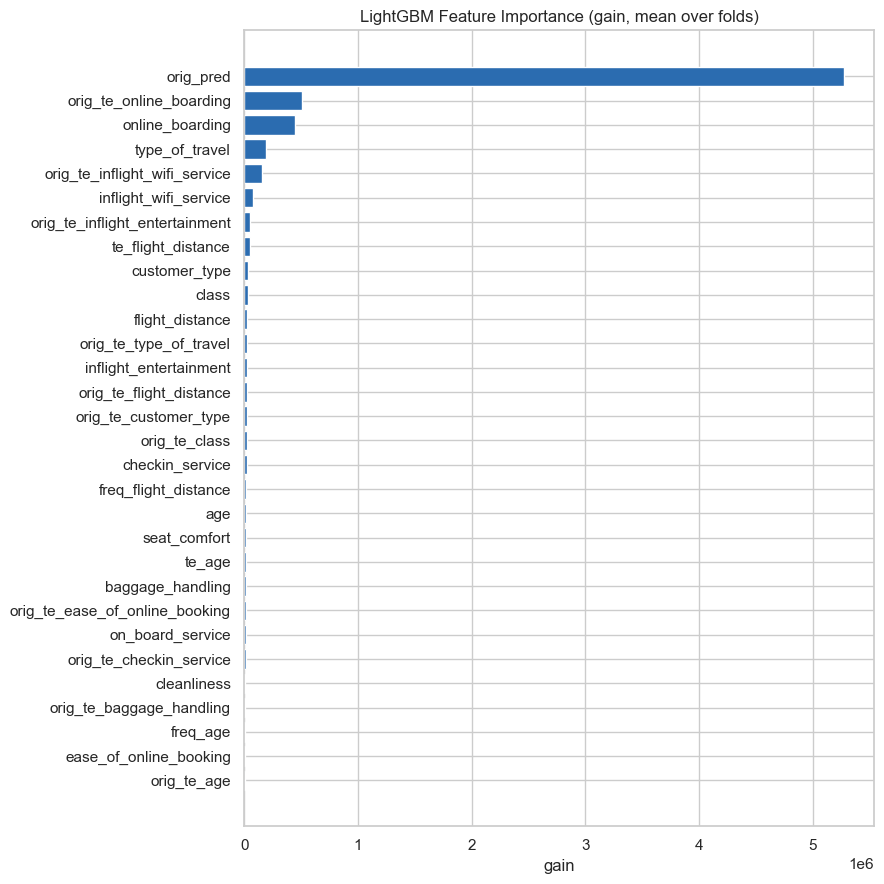

In [68]:
# LightGBM feature importance (gain, averaged over folds)
if lgb_importance:
    imp = pd.concat(lgb_importance, axis=1).mean(axis=1).sort_values(ascending=False)
    top = imp.head(30)

    fig, ax = plt.subplots(figsize=(9, 9))
    ax.barh(top.index[::-1], top.values[::-1], color='#2b6cb0')
    ax.set_title('LightGBM Feature Importance (gain, mean over folds)')
    ax.set_xlabel('gain')
    plt.tight_layout(); plt.show()
else:
    print('No importances: LightGBM predictions were loaded from disk, not retrained.')

`orig_pred` dominates the chart, but gain measures how much a feature is *used*, not what it adds: on its own
the ablation put it at only +0.0002. It is a ready-made summary of everything else, so the trees split on it
first, and the raw columns it summarises lose gain to it. The more telling part is further down:
`orig_te_online_boarding`, `orig_te_inflight_wifi_service` and `te_flight_distance` rank above most raw columns,
which is where the encodings' contribution shows up.

## 5. Submission

In [69]:
sub = sample_sub[['id']].merge(
    pd.DataFrame({'id': test_df['id'].values, TARGET: final_test}), on='id', how='left'
)
assert sub[TARGET].notna().all(), 'some test ids have no prediction'
assert sub[TARGET].between(0, 1).all()

sub.to_csv(f'{SUB_DIR}/submission.csv', index=False)
print(f'saved {SUB_DIR}/submission.csv  shape={sub.shape}  blend={BEST}')
sub.head()

saved ../submission/submission.csv  shape=(299844, 2)  blend=weighted rank


,id,satisfaction
0,699635,0.517888
1,699636,0.589626
2,699637,0.659590
3,699638,0.457537
4,699639,0.366448


## 6. Results & Next Steps

| round | configuration | model | OOF AUC | public LB |
|---|---|---|---|---|
| 1 | raw features | LightGBM | 0.959041 | |
| 1 | raw features | XGBoost | 0.958899 | |
| 1 | raw features | rank blend, LightGBM 0.61 / XGBoost 0.39 | 0.959144 | 0.95851 |
| 2 | raw features | CatBoost | 0.958711 | |
| 2 | raw features | rank blend, LightGBM 0.53 / XGBoost 0.24 / CatBoost 0.22 | 0.959183 | 0.95859 |
| 3 | + orig_pred, orig_te, freq, te | LightGBM | 0.960585 | |
| 3 | + orig_pred, orig_te, freq, te | XGBoost | 0.960590 | |
| 3 | + orig_pred, orig_te, freq, te | CatBoost | 0.960635 | |
| 3 | + orig_pred, orig_te, freq, te | rank blend, LightGBM 0.28 / XGBoost 0.27 / CatBoost 0.45 | **0.960780** | **0.96029** |

- **Round 3 lifted every model by 0.0015–0.0019**, and CatBoost went from weakest to strongest single model.
- **The models now agree more** (Spearman 0.987–0.991, up from 0.978–0.985): the encodings give all three the same
  view of the data, so the blend adds only +0.00015 over the best single model.
- **LightGBM now early-stops at 314–921 iterations** (703–1,170 before). The encodings hand it the signal in
  fewer splits, and it starts to overfit sooner.
- **The public LB has landed 0.0005–0.0006 below OOF in all three submissions**, so CV remains a reliable guide.

Round 4 (this version) extends the `te` encodings and tests their smoothing; see section 3c.

Further ideas:

- **Tuning.** Given the earlier stopping, a lower learning rate with stronger regularisation is worth a run.
- **10 folds.** Beyond the usual small gain, every `te` lookup would then be built on 90% of train instead of
  80%.
- **Seed averaging** for a small, reliable gain once the feature set is settled.
- **CatBoost with the ratings as categoricals**, for blend diversity now that the models have converged.